# 📚 Book Sales Data Analysis Using Python

## Project Overview

This project analyzes book sales data using Python to identify
patterns and insights related to book ratings, genres, languages,
authors, publishers, pricing, revenue, and units sold.

The analysis follows a complete data analytics workflow:
data loading, data inspection, data cleaning, exploratory data
analysis, visualization, and business insights.

## 1. Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   


## 2. Load the Dataset

The dataset is loaded into a Pandas DataFrame for further
analysis and processing.

In [2]:
df = pd.read_csv('Books_Data_Clean.csv')

## 3. Initial Data Inspection

In this section, the dataset structure is examined using
sample records, dimensions, column names, and data types.
This helps understand the dataset before performing cleaning.

In [3]:
df.head()

,index,Publishing Year,Book Name,Author,language_code,Author_Rating,Book_average_rating,Book_ratings_count,genre,gross sales,publisher revenue,sale price,sales rank,Publisher,units sold
0,0,1975.0,Beowulf,"Unknown, Seamus Heaney",en-US,Novice,3.42,155903,genre fiction,34160.0,20496.0,4.88,1,HarperCollins Publishers,7000
1,1,1987.0,Batman: Year One,"Frank Miller, David Mazzucchelli, Richmond Lew...",eng,Intermediate,4.23,145267,genre fiction,12437.5,7462.5,1.99,2,HarperCollins Publishers,6250
2,2,2015.0,Go Set a Watchman,Harper Lee,eng,Novice,3.31,138669,genre fiction,47795.0,28677.0,8.69,3,"Amazon Digital Services, Inc.",5500
3,3,2008.0,When You Are Engulfed in Flames,David Sedaris,en-US,Intermediate,4.04,150898,fiction,41250.0,24750.0,7.50,3,Hachette Book Group,5500
4,4,2011.0,Daughter of Smoke & Bone,Laini Taylor,eng,Intermediate,4.04,198283,genre fiction,37952.5,22771.5,7.99,4,Penguin Group (USA) LLC,4750


In [4]:
df.dtypes

index                    int64
Publishing Year        float64
Book Name               object
Author                  object
language_code           object
Author_Rating           object
Book_average_rating    float64
Book_ratings_count       int64
genre                   object
gross sales            float64
publisher revenue      float64
sale price             float64
sales rank               int64
Publisher               object
units sold               int64
dtype: object

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1070 entries, 0 to 1069
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   index                1070 non-null   int64  
 1   Publishing Year      1069 non-null   float64
 2   Book Name            1047 non-null   object 
 3   Author               1070 non-null   object 
 4   language_code        1017 non-null   object 
 5   Author_Rating        1070 non-null   object 
 6   Book_average_rating  1070 non-null   float64
 7   Book_ratings_count   1070 non-null   int64  
 8   genre                1070 non-null   object 
 9   gross sales          1070 non-null   float64
 10  publisher revenue    1070 non-null   float64
 11  sale price           1070 non-null   float64
 12  sales rank           1070 non-null   int64  
 13  Publisher            1070 non-null   object 
 14  units sold           1070 non-null   int64  
dtypes: float64(5), int64(4), object(6)
mem

## 4. Statistical Summary

This section provides descriptive statistics for numerical
columns to understand the central tendency, spread, and
range of the dataset.

In [6]:
df.describe()

,index,Publishing Year,Book_average_rating,Book_ratings_count,gross sales,publisher revenue,sale price,sales rank,units sold
count,1070.000000,1069.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000
mean,534.500000,1971.377923,4.007000,94909.913084,1856.622944,843.281030,4.869561,611.652336,9676.980374
std,309.026698,185.080257,0.247244,31513.242518,3936.924240,2257.596743,3.559919,369.849830,15370.571306
min,0.000000,-560.000000,2.970000,27308.000000,104.940000,0.000000,0.990000,1.000000,106.000000
25%,267.250000,1985.000000,3.850000,70398.000000,372.465000,0.000000,1.990000,287.500000,551.250000
50%,534.500000,2003.000000,4.015000,89309.000000,809.745000,273.078000,3.990000,595.500000,3924.000000
75%,801.750000,2010.000000,4.170000,113906.500000,1487.957500,721.180500,6.990000,932.500000,5312.250000
max,1069.000000,2016.000000,4.770000,206792.000000,47795.000000,28677.000000,33.860000,1273.000000,61560.000000


## 5. Duplicate Record Analysis

Duplicate records are checked to ensure that repeated
observations do not affect the accuracy of the analysis.

In [7]:
df.duplicated().sum()

0

## 6. Missing Value Analysis

Missing values are identified to determine which columns
require cleaning or further treatment before analysis.

In [8]:
df.isna().sum()

index                   0
Publishing Year         1
Book Name              23
Author                  0
language_code          53
Author_Rating           0
Book_average_rating     0
Book_ratings_count      0
genre                   0
gross sales             0
publisher revenue       0
sale price              0
sales rank              0
Publisher               0
units sold              0
dtype: int64

## 7. Unique Value Analysis

This section examines the number of unique values in each
column of the dataset.

Understanding unique values helps identify categorical
variables, measure data variety, and detect potential data
quality issues before performing further analysis.

In [9]:
df.nunique()

index                  1070
Publishing Year         150
Book Name              1045
Author                  735
language_code             8
Author_Rating             4
Book_average_rating     134
Book_ratings_count     1064
genre                     4
gross sales             831
publisher revenue       610
sale price              149
sales rank              865
Publisher                 9
units sold              491
dtype: int64

## 8. Book Publishing Year Analysis

This analysis examines the distribution of books across
publishing years to identify the periods with greater
representation in the dataset.

In [10]:
df = df[df["Publishing Year"] > 1990]

In [11]:
df.dropna(subset=["Book Name"], inplace=True)

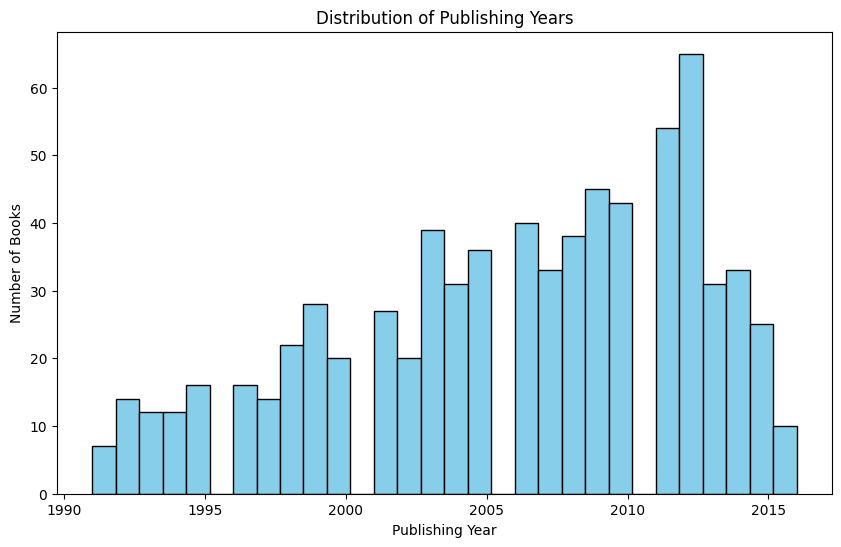

In [12]:
plt.figure(figsize=(10, 6))
plt.hist(df["Publishing Year"], bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Publishing Years")
plt.xlabel("Publishing Year")
plt.ylabel("Number of Books")
plt.show()

## 9. Book Distribution by Genre

This section analyzes the number of books belonging to
different genres and identifies the most represented genres
in the dataset.

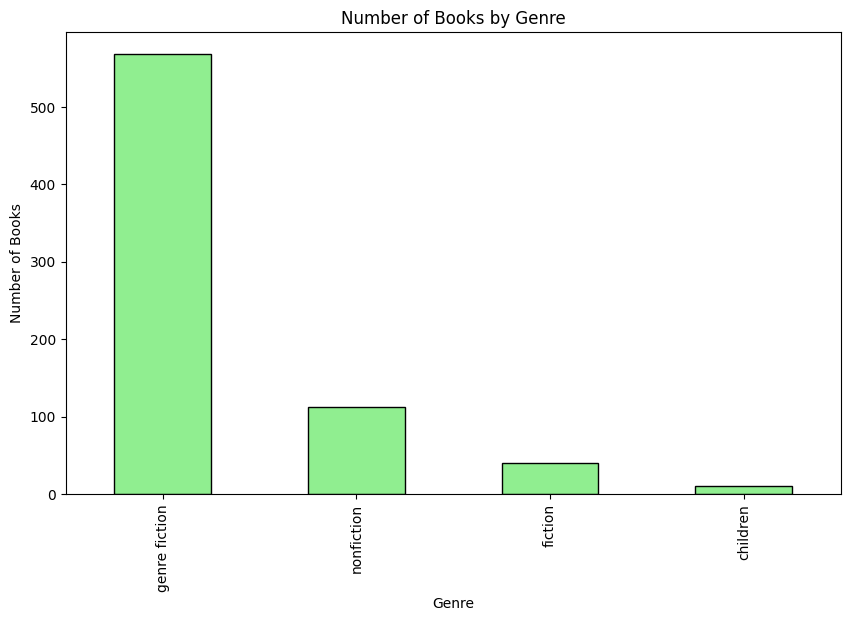

In [13]:
df['genre'].value_counts().plot(kind='bar', figsize=(10, 6), color='lightgreen', edgecolor='black')
plt.title("Number of Books by Genre")
plt.xlabel("Genre")
plt.ylabel("Number of Books")
plt.show()

## 10. Author Rating Analysis

This analysis compares author rating categories and examines
their relationship with reader engagement based on the number
of book ratings.

In [14]:
df.groupby('Author')['Book_average_rating'].mean().sort_values(ascending=False).reset_index()

,Author,Book_average_rating
0,George R.R. Martin,4.560000
1,Sarah J. Maas,4.526000
2,"Hiromu Arakawa, Akira Watanabe",4.490000
3,Cassandra Clare,4.480000
4,Robert Kirkman,4.430000
...,...,...
465,Chetan Bhagat,3.273333
466,Audrey Niffenegger,3.230000
467,"Herman Koch, Sam Garrett",3.220000
468,P.D. James,3.210000


## 11. Book Ratings Distribution by Genre

A boxplot is used to compare the distribution of book ratings
across genres, including their median, spread, and potential
outliers.

C:\Users\Ritikesh Raj\AppData\Local\Temp\ipykernel_19480\4203305118.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


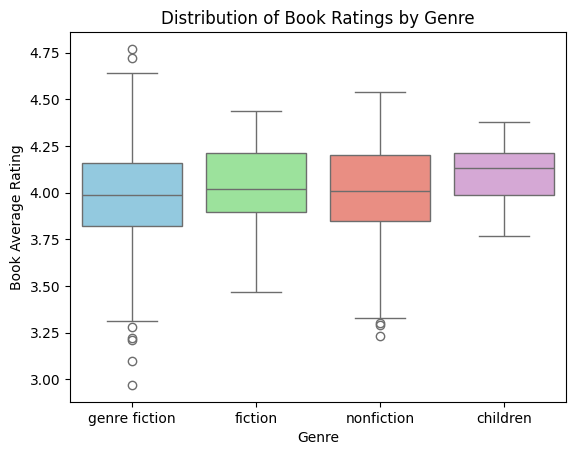

In [15]:
sns.boxplot(
    x='genre',
    y='Book_average_rating',
    data=df,
    palette=['skyblue', 'lightgreen', 'salmon', 'plum']
)

plt.title("Distribution of Book Ratings by Genre")
plt.xlabel("Genre")
plt.ylabel("Book Average Rating")
plt.show()

## 12. Relationship Between Sale Price and Units Sold

This analysis investigates whether book pricing is associated
with the number of units sold.

A scatter plot is used to visualize the relationship between
sale price and sales volume.

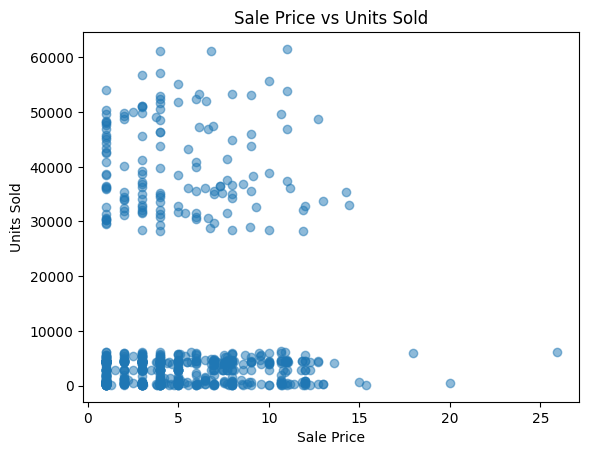

In [16]:
plt.scatter(df["sale price"], df["units sold"], alpha=0.5)
plt.title("Sale Price vs Units Sold")
plt.xlabel("Sale Price")
plt.ylabel("Units Sold")
plt.show()

## 13. Distribution of Books by Language

This section analyzes the number of books available under
each language code to understand the language composition
of the dataset.

In [17]:
language_counts = df['language_code'].value_counts()

In [18]:
top_languages = language_counts.head(5)

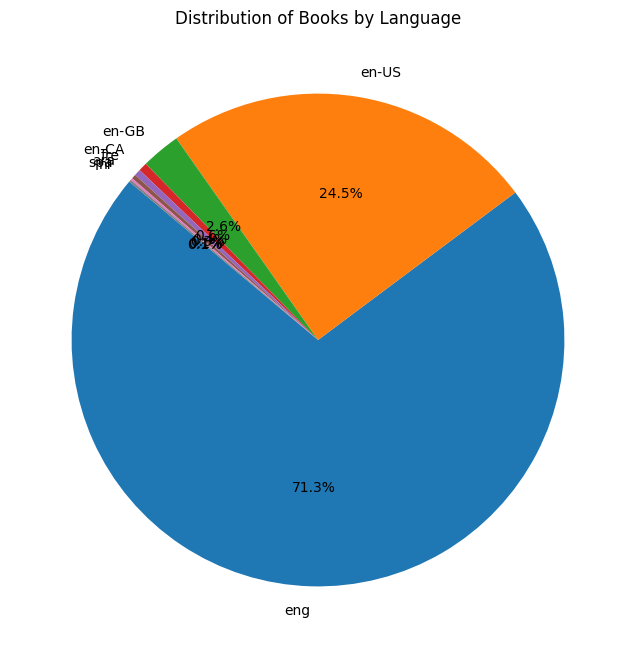

In [19]:
plt.figure(figsize=(8, 8))
plt.pie(language_counts, labels=language_counts.index, autopct='%1.1f%%', startangle=140)
plt.title("Distribution of Books by Language")
plt.show()

## 14. Publisher Revenue Analysis

This section compares publishers based on total publisher
revenue to identify publishers with stronger revenue
performance in the dataset.

In [20]:
df.groupby('Publisher ')['publisher revenue'].sum().sort_values(ascending=False).reset_index()

,Publisher,publisher revenue
0,Penguin Group (USA) LLC,128647.002
1,Random House LLC,120250.824
2,"Amazon Digital Services, Inc.",109249.368
3,HarperCollins Publishers,80419.890
4,Hachette Book Group,78907.236
5,Simon and Schuster Digital Sales Inc,29628.912
6,Macmillan,24943.146
7,HarperCollins Christian Publishing,2135.670
8,HarperCollins Publishing,2127.654


## 15. Book Rating vs Reader Engagement

This analysis examines whether books with higher average
ratings also receive a higher number of ratings.

The relationship is visualized using a scatter plot.

In [21]:
df.groupby('Author_Rating')['Book_ratings_count'].mean().sort_values(ascending=False).reset_index()

,Author_Rating,Book_ratings_count
0,Famous,98915.710526
1,Intermediate,97485.152074
2,Excellent,85308.305085
3,Novice,82425.869565


## 16. Distribution of Books by Language

This section analyzes the number of books available in each
language. The language codes are grouped and sorted in
descending order to identify the most common languages in
the dataset.

In [22]:
df.groupby('language_code').size().sort_values(ascending=False).reset_index()

,language_code,0
0,eng,500
1,en-US,172
2,en-GB,18
3,en-CA,4
4,fre,3
5,ara,2
6,nl,1
7,spa,1


## 17. Book Average Rating vs Book Ratings Count

This analysis examines the relationship between a book's average
rating and the number of ratings it has received.

A scatter plot is used to visualize whether books with higher
average ratings tend to receive more ratings from readers.

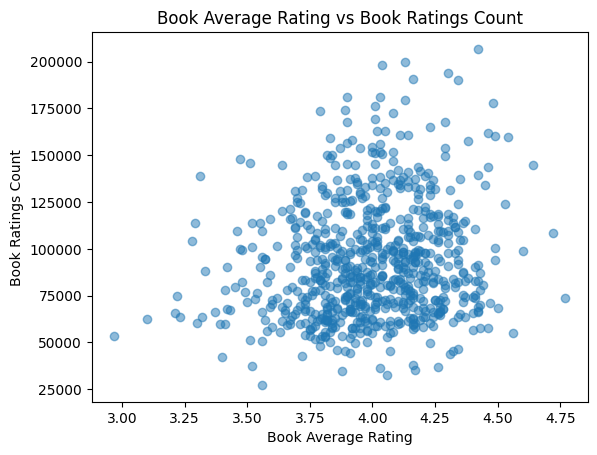

In [23]:
plt.scatter(df['Book_average_rating'], df['Book_ratings_count'], alpha=0.5)
plt.title("Book Average Rating vs Book Ratings Count")
plt.xlabel("Book Average Rating")
plt.ylabel("Book Ratings Count")
plt.show()

## 18. Author-Level Sales Analysis

This section aggregates the dataset at the author level to
summarize the available numerical information for each author.

The grouped data can be used to compare authors based on
sales, ratings, revenue, units sold, and other performance
metrics.


In [24]:
total_gross_sales_by_author = df.groupby('Author').sum()

In [25]:
total_gross_sales_by_author

,index,Publishing Year,Book Name,language_code,Author_Rating,Book_average_rating,Book_ratings_count,genre,gross sales,publisher revenue,sale price,sales rank,Publisher,units sold
Author,,,,,,,,,,,,,,
A.S.A. Harrison,775,2013.0,The Silent Wife,eng,Novice,3.30,60323,nonfiction,784.16,470.496,6.76,897,"Amazon Digital Services, Inc.",28728
Abbi Glines,1045,4025.0,"Fallen Too Far (Too Far, #1)Never Too Far (Too...",engeng,ExcellentExcellent,8.42,236487,genre fictiongenre fiction,2990.16,1794.096,9.81,1188,Penguin Group (USA) LLCAmazon Digital Services...,30782
Adam Johnson,931,2012.0,The Orphan Master's Son,eng,Excellent,4.06,52765,genre fiction,108.90,65.340,0.99,1097,Macmillan,4320
"Adam Mansbach, Ricardo CortÃ©s",800,2011.0,Go the Fuck to Sleep,eng,Excellent,4.26,71816,genre fiction,113.85,68.310,0.99,930,"Amazon Digital Services, Inc.",2916
Alan Bradley,493,2009.0,The Sweetness at the Bottom of the Pie,eng,Intermediate,3.81,99841,genre fiction,1757.25,1054.350,10.65,545,Penguin Group (USA) LLC,4455
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Wendelin Van Draanen,914,2001.0,Flipped,en-US,Intermediate,3.94,79264,nonfiction,109.89,0.000,0.99,1072,"Amazon Digital Services, Inc.",4360
"Yana Toboso, Tomo Kimura",821,2007.0,é»’åŸ·äº‹ I [Kuroshitsuji I],eng,Excellent,4.37,74378,nonfiction,1366.86,820.116,11.99,960,Penguin Group (USA) LLC,2889
Zadie Smith,474,1999.0,White Teeth,en-US,Intermediate,3.75,82474,fiction,167.31,100.386,0.99,524,"Amazon Digital Services, Inc.",4563


## 19. Distribution of Units Sold by Author Rating

This section analyzes the distribution of units sold across
different author rating categories.

A boxplot is used to compare the median, spread, and outliers
of units sold for each author rating category.

C:\Users\Ritikesh Raj\AppData\Local\Temp\ipykernel_19480\1950445812.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(


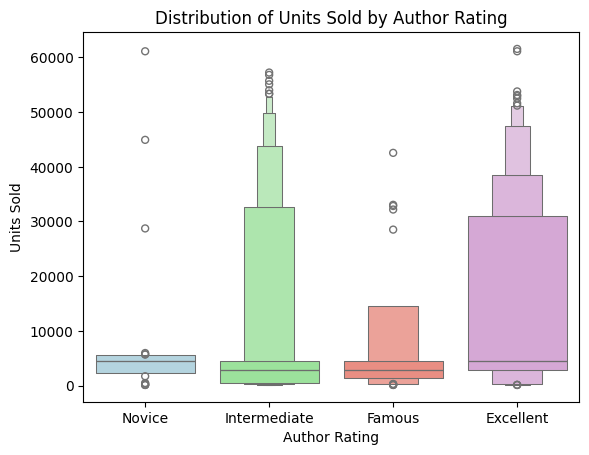

In [26]:
sns.boxenplot(
    x='Author_Rating', 
    y='units sold', 
    data=df,
    palette=['lightblue', 'lightgreen', 'salmon', 'plum']
    )
plt.title("Distribution of Units Sold by Author Rating")
plt.xlabel("Author Rating")
plt.ylabel("Units Sold")
plt.show()


## 20. Total Units Sold by Publishing Year

This section analyzes the total number of units sold for each
publishing year.

The data is grouped by publishing year and the total units sold
are calculated. A line chart is used to visualize changes in
sales volume over time.

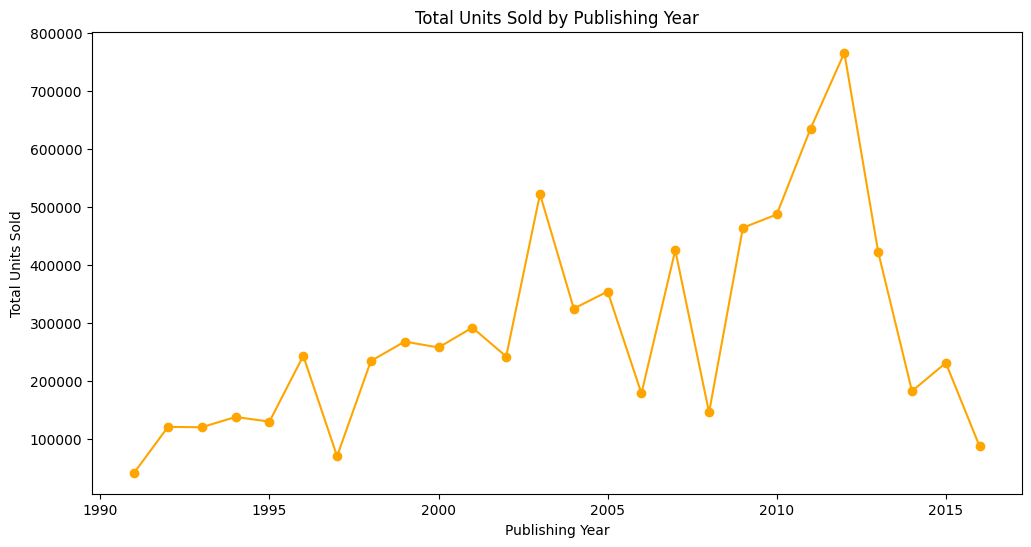

In [27]:
df.groupby('Publishing Year')['units sold'].sum().plot(kind='line', figsize=(12, 6), color='orange', marker='o')
plt.title("Total Units Sold by Publishing Year")
plt.xlabel("Publishing Year")
plt.ylabel("Total Units Sold")
plt.show()

# 💡 Key Insights

1. English-language books represent the largest portion of
   the dataset.

2. Book ratings vary across different genres, with some
   genres showing greater rating variability.

3. Sale price and units sold can be analyzed to understand
   potential pricing and sales relationships.

4. Publisher-level analysis helps identify differences in
   revenue performance.

5. Author-level analysis provides insights into sales and
   reader engagement.

6. Publishing-year analysis helps identify changes in book
   sales over time.

# 📝 Conclusion

This project demonstrates an end-to-end exploratory data
analysis workflow using Python.

The analysis combines data cleaning, statistical analysis,
grouping, aggregation, and visualization to extract
meaningful insights from book sales data.

The project demonstrates practical skills in Pandas,
NumPy, Matplotlib, and Seaborn and can be used as a
portfolio project for Data Analyst roles.